# NLP Practical File

---

**Name :** Anish Bhalla  
**Roll No. :** 22/28074  
**Course :** BSc. (Hons) Computer Science

---

In [1]:
# Path Checker
import os
for dirname, _, filenames in os.walk('/kaggle/working/'):
    for filename in filenames:
        print(os.path.join(dirname,filename))

/kaggle/working/IMDB Dataset.csv
/kaggle/working/shakespeare.txt
/kaggle/working/glove.6B.zip
/kaggle/working/.virtual_documents/__notebook_source__.ipynb
/kaggle/working/glove/glove.6B.100d.txt
/kaggle/working/glove/glove.6B.300d.txt
/kaggle/working/glove/glove.6B.200d.txt
/kaggle/working/glove/glove.6B.50d.txt


In [2]:
# Installing IMDB Dataset

#!pip install kaggle --upgrade -q
#import kaggle
#kaggle.api.dataset_download_files(
   # 'lakshmi25npathi/imdb-dataset-of-50k-movie-reviews',
    #path = '/kaggle/working/',
    #unzip=True
#)

import pandas as pd
df = pd.read_csv('/kaggle/working/IMDB Dataset.csv')
print(df.shape)
print(df.head())

(50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [3]:
# Install Shakespeare txt file

import kaggle
kaggle.api.dataset_download_files(
    'mohammedmohsen0404/shakespeare-txt',
     path = '/kaggle/working/',
     unzip=True
)

print("Done!")

Dataset URL: https://www.kaggle.com/datasets/mohammedmohsen0404/shakespeare-txt
Done!


## Practical 1 — Text Pre-processing

**Aim:** Clean and prepare a raw text corpus so it is ready for NLP tasks.

**Steps Involved:**

1. **Lowercasing** — Converts all characters to lowercase (e.g., `NLP` → `nlp`). This helps maintain uniformity and prevents treating `Language` and `language` as different words.

2. **Tokenization** — Breaks text into smaller units called tokens (usually words). For example: `"Natural Language Processing is amazing"` → `['natural', 'language', 'processing', 'is', 'amazing']`

3. **Punctuation Removal** — Removes special characters such as `!`, `,`, `.`, `(`, `)` which usually do not add meaningful information.

4. **Stop-word Removal** — Removes very common words like *is*, *the*, *and*, *to* which carry little meaning. This reduces noise and improves model efficiency.

5. **Stemming** — Reduces words to their root form using heuristic rules.
   - Examples: `running → run`, `playing → play`, `processing → process`
   - Fast but may produce non-dictionary words (e.g., `studies → studi`)

6. **Lemmatization** — Converts words to their proper dictionary (base) form using vocabulary analysis.
   - Examples: `better → good`, `running → run`, `studies → study`
   - More accurate than stemming but computationally slower.

In [4]:
import nltk
import string
import numpy as np
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required NLTK data (run once)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

# ── Sample text corpus ──────────────────────────────────────────────────────
text = """
Natural Language Processing (NLP) is amazing! It allows computers to
understand human language.
Email me at example_user@gmail.com on 12/10/2025.
"""

# ── Step 1: Convert to Lowercase ─────────────────────────────────────────────
text_lower = text.lower()

# ── Step 2: Tokenization ─────────────────────────────────────────────────────
tokens = word_tokenize(text_lower)

# ── Step 3: Remove Punctuation ───────────────────────────────────────────────
tokens_no_punct = [word for word in tokens if word not in string.punctuation]

# ── Step 4: Remove Stop Words ────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens_no_punct if word not in stop_words]

# ── Step 5: Stemming ─────────────────────────────────────────────────────────
stemmer = PorterStemmer()
stemmed_words = [stemmer.stem(word) for word in filtered_tokens]

# ── Step 6: Lemmatization ────────────────────────────────────────────────────
lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in filtered_tokens]

# ── Results ───────────────────────────────────────────────────────────────────
print("Tokens:", tokens)
print("After Stopword Removal:", filtered_tokens)
print("Stemmed Words:", stemmed_words)
print("Lemmatized Words:", lemmatized_words)

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Tokens: ['natural', 'language', 'processing', '(', 'nlp', ')', 'is', 'amazing', '!', 'it', 'allows', 'computers', 'to', 'understand', 'human', 'language', '.', 'email', 'me', 'at', 'example_user', '@', 'gmail.com', 'on', '12/10/2025', '.']
After Stopword Removal: ['natural', 'language', 'processing', 'nlp', 'amazing', 'allows', 'computers', 'understand', 'human', 'language', 'email', 'example_user', 'gmail.com', '12/10/2025']
Stemmed Words: ['natur', 'languag', 'process', 'nlp', 'amaz', 'allow', 'comput', 'understand', 'human', 'languag', 'email', 'example_us', 'gmail.com', '12/10/2025']
Lemmatized Words: ['natural', 'language', 'processing', 'nlp', 'amazing', 'allows', 'computer', 'understand', 'human', 'language', 'email', 'example_user', 'gmail.com', '12/10/2025']


**Summary Table:**

| Step | Operation | Output |
|------|-----------|--------|
| 1 | Original Text | Natural Language Processing (NLP) is amazing! |
| 2 | Lowercasing | natural language processing (nlp) is amazing! |
| 3 | Tokenization | `['natural', 'language', 'processing', '(', 'nlp', ')', 'is', 'amazing', '!']` |
| 4 | Remove Punctuation | `['natural', 'language', 'processing', 'nlp', 'is', 'amazing']` |
| 5 | Remove Stopwords | `['natural', 'language', 'processing', 'nlp', 'amazing']` |
| 6 | Stemming | `['natur', 'languag', 'process', 'nlp', 'amaz']` |
| 7 | Lemmatization | `['natural', 'language', 'processing', 'nlp', 'amazing']` |

---
## Practical 2 — Regex Pattern Extraction

**Aim:** Use Regular Expressions (regex) to automatically extract useful information from unstructured text.

**Regex Patterns Table:**

| Data Type | Regex Pattern | Description | Example Match |
|-----------|--------------|-------------|---------------|
| Email Username | `\b([a-zA-Z0-9._%+-]+)@` | Captures the username before `@` | `john_doe123` |
| Hashtags | `#\w+` | Matches words starting with `#` | `#NLP` |
| Date (DD/MM/YYYY) | `\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b` | Matches dates with `/` or `-` | `12/10/2025` |
| Date (YYYY-MM-DD) | `\b\d{4}-\d{2}-\d{2}\b` | Matches ISO format date | `2025-10-12` |
| Phone (with country code) | `\+?\d{1,3}[-.\s]?\d{3}[-.\s]?\d{3}[-.\s]?\d{4}` | Matches phone with optional country code | `+1-9876543210` |
| Phone (standard) | `\d{3}[-.\s]?\d{3}[-.\s]?\d{4}` | Matches 10-digit phone numbers | `987-654-3210` |

In [5]:
import re

# ── Sample text ───────────────────────────────────────────────────────────────
sample_text = """
Contact john_doe123@gmail.com or jane.smith@company.org.
Use hashtag #NLP and #MachineLearning.
Event date: 12/10/2025 or 2025-10-12.
Call me at +1-9876543210 or 987-654-3210.
"""

# ── 1. Extract usernames from email addresses ────────────────────────────────
email_usernames = re.findall(r'\b([a-zA-Z0-9._%+-]+)@', sample_text)

# ── 2. Extract hashtags ───────────────────────────────────────────────────────
hashtags = re.findall(r'#\w+', sample_text)

# ── 3. Extract dates (multiple formats) ─────────────────────────────────────
dates = re.findall(r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b|\b\d{4}-\d{2}-\d{2}\b', sample_text)

# ── 4. Extract phone numbers ──────────────────────────────────────────────────
phone_numbers = re.findall(r'\+?\d{1,3}[-.\s]?\d{3}[-.\s]?\d{3}[-.\s]?\d{4}', sample_text)

# ── Print results ─────────────────────────────────────────────────────────────
print("Email Usernames:", email_usernames)
print("Hashtags:", hashtags)
print("Dates:", dates)
print("Phone Numbers:", phone_numbers)

Email Usernames: ['john_doe123', 'jane.smith']
Hashtags: ['#NLP', '#MachineLearning']
Dates: ['12/10/2025', '2025-10-12']
Phone Numbers: ['+1-9876543210']


---
## Practical 3 — Most Common Words (Word Frequency)

**Aim:** Count and display the most frequently used meaningful words in a given text, after excluding stop words.

This is useful for quickly understanding what a document is mainly about — the words with the highest frequency are usually the most important topics.

In [6]:
from collections import Counter

# We reuse the filtered_tokens from Practical 1 (stop words already removed)
# Count word frequency
word_freq = Counter(filtered_tokens)

# Display the most common 10 words
most_common_words = word_freq.most_common(10)

print("Most Common Words (Excluding Stopwords):")
for word, freq in most_common_words:
    print(f"{word} : {freq}")

Most Common Words (Excluding Stopwords):
language : 2
natural : 1
processing : 1
nlp : 1
amazing : 1
allows : 1
computers : 1
understand : 1
human : 1
email : 1


---
## Practical 4 — TF-IDF Matrix

**Aim:** Build a TF-IDF (Term Frequency – Inverse Document Frequency) matrix for a set of documents.

**What is TF-IDF?**
- **TF (Term Frequency):** How often a word appears in *one* document.
- **IDF (Inverse Document Frequency):** How rare a word is *across all* documents — rare words get higher scores.
- **TF-IDF = TF × IDF** — Words that are common in one document but rare overall get a high score, making them the most *distinctive* words for that document.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# ── Sample documents ──────────────────────────────────────────────────────────
documents = [
    "I love machine learning",
    "Machine learning is fun",
    "I love coding"
]

# ── Build TF-IDF Matrix ───────────────────────────────────────────────────────
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)

# ── Display as a readable DataFrame ──────────────────────────────────────────
df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)
print(df)

     coding       fun        is  learning      love   machine
0  0.000000  0.000000  0.000000  0.577350  0.577350  0.577350
1  0.000000  0.562829  0.562829  0.428046  0.000000  0.428046
2  0.795961  0.000000  0.000000  0.000000  0.605349  0.000000


---
## Practical 5 — Statistical Language Model (Unigram & Bigram with Add-One Smoothing)

**Aim:** Build a simple statistical language model and compute the probability of sentences.

**Key Concepts:**
- **Unigram probability** — How likely is a single word? `P(word) = count(word) / total_words`
- **Bigram probability** — How likely is a word given the previous word? `P(w2|w1) = count(w1,w2) / count(w1)`
- **Add-One (Laplace) Smoothing** — Add 1 to all counts so we never get zero probability for unseen words. Formula: `P(word) = (count + 1) / (total + vocab_size)`

In [8]:
from collections import defaultdict

# ── Training corpus ───────────────────────────────────────────────────────────
corpus = [
    "i love machine learning",
    "machine learning is fun",
    "i love coding"
]

tokens = [sentence.split() for sentence in corpus]

# ── Build vocabulary ──────────────────────────────────────────────────────────
vocab = set()
for sentence in tokens:
    vocab.update(sentence)
vocab = list(vocab)
V = len(vocab)   # vocabulary size
print("Vocabulary:", vocab)

# ── Unigram Model ────────────────────────────────────────────────────────────
unigram_counts = defaultdict(int)
for sentence in tokens:
    for word in sentence:
        unigram_counts[word] += 1
total_words = sum(unigram_counts.values())

# ── Bigram Model ─────────────────────────────────────────────────────────────
bigram_counts = defaultdict(int)
word_counts   = defaultdict(int)
for sentence in tokens:
    for i in range(len(sentence) - 1):
        bigram = (sentence[i], sentence[i+1])
        bigram_counts[bigram] += 1
        word_counts[sentence[i]] += 1

# ── Add-One Smoothing ─────────────────────────────────────────────────────────
unigram_probs = {}
for word in unigram_counts:
    unigram_probs[word] = (unigram_counts[word] + 1) / (total_words + V)

bigram_probs = {}
for (w1, w2) in bigram_counts:
    bigram_probs[(w1, w2)] = (bigram_counts[(w1, w2)] + 1) / (word_counts[w1] + V)

# ── Sentence Probability Function ────────────────────────────────────────────
def sentence_probability(sentence, model="unigram"):
    words = sentence.split()
    prob = 1
    if model == "unigram":
        for word in words:
            prob *= unigram_probs.get(word, 1 / (total_words + V))
    elif model == "bigram":
        for i in range(len(words) - 1):
            prob *= bigram_probs.get((words[i], words[i+1]), 1 / V)
    return prob

# ── Test Sentences ────────────────────────────────────────────────────────────
s1 = "i love machine learning"
s2 = "machine learning is fun"
s3 = "i love ai"

print("\nUnigram Probabilities:")
print(s1, ":", sentence_probability(s1, "unigram"))
print(s2, ":", sentence_probability(s2, "unigram"))
print(s3, ":", sentence_probability(s3, "unigram"))

print("\nBigram Probabilities:")
print(s1, ":", sentence_probability(s1, "bigram"))
print(s2, ":", sentence_probability(s2, "bigram"))
print(s3, ":", sentence_probability(s3, "bigram"))

Vocabulary: ['is', 'love', 'coding', 'fun', 'i', 'machine', 'learning']

Unigram Probabilities:
i love machine learning : 0.0007716049382716049
machine learning is fun : 0.0003429355281207133
i love ai : 0.0015432098765432098

Bigram Probabilities:
i love machine learning : 0.024691358024691357
machine learning is fun : 0.020833333333333332
i love ai : 0.047619047619047616


---
## Practical 6 — POS Tagging, Noun Extraction & POS Frequency

**Aim:** Tag every word in a text with its Part-of-Speech (POS), extract all nouns, and create a frequency dictionary of all POS tags.

**Common POS Tags:**
- `NN` = Noun (singular), `NNS` = Noun (plural), `NNP` = Proper Noun
- `VB` = Verb, `VBZ` = Verb (3rd person), `VBG` = Verb (gerund)
- `JJ` = Adjective, `RB` = Adverb, `IN` = Preposition, `DT` = Determiner

In [9]:
import nltk
from collections import Counter
import pandas as pd

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')

# ── Input text (simulating a text file) ───────────────────────────────────────
text = "Natural language processing is a fascinating field of artificial intelligence. It deals with text and language data."

# ── Tokenization + POS Tagging ────────────────────────────────────────────────
words    = nltk.word_tokenize(text)
pos_tags = nltk.pos_tag(words)

# ── Extract Nouns ─────────────────────────────────────────────────────────────
# Noun tags: NN (singular), NNS (plural), NNP (proper noun)
nouns = [word for word, tag in pos_tags if tag.startswith('NN')]

# ── POS Frequency Dictionary ──────────────────────────────────────────────────
pos_freq = Counter(tag for word, tag in pos_tags)

# ── Display as clean DataFrames ───────────────────────────────────────────────
df_tags = pd.DataFrame(pos_tags, columns=["Word", "POS Tag"])
df_freq = pd.DataFrame(pos_freq.items(), columns=["POS Tag", "Frequency"])
df_freq = df_freq.sort_values(by="Frequency", ascending=False)

# ── Output ────────────────────────────────────────────────────────────────────
print("=" * 50)
print("POS TAGGING RESULTS")
print("=" * 50)
print(df_tags)

print("\n" + "=" * 50)
print("EXTRACTED NOUNS")
print("=" * 50)
print(", ".join(nouns))

print("\n" + "=" * 50)
print("POS TAG FREQUENCY")
print("=" * 50)
print(df_freq.to_string(index=False))

POS TAGGING RESULTS
            Word POS Tag
0        Natural      JJ
1       language      NN
2     processing      NN
3             is     VBZ
4              a      DT
5    fascinating      JJ
6          field      NN
7             of      IN
8     artificial      JJ
9   intelligence      NN
10             .       .
11            It     PRP
12         deals     VBZ
13          with      IN
14          text      NN
15           and      CC
16      language      NN
17          data     NNS
18             .       .

EXTRACTED NOUNS
language, processing, field, intelligence, text, language, data

POS TAG FREQUENCY
POS Tag  Frequency
     NN          6
     JJ          3
    VBZ          2
     IN          2
      .          2
     DT          1
    PRP          1
     CC          1
    NNS          1


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


---
## Practical 7 — Named Entity Recognition (NER)

**Aim:** Automatically identify and classify named entities (real-world objects) in news headlines.

**What is NER?**  
NER finds words/phrases that refer to specific things in the real world:
- `PERSON` → *Narendra Modi*, *Elon Musk*
- `GPE` (Geo-Political Entity) → *India*, *United States*, *California*
- `ORGANIZATION` → *Google*, *SpaceX*, *NASA*

In [10]:
import nltk

nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

# ── Input: Collection of news headlines ───────────────────────────────────────
headlines = [
    "Prime Minister Narendra Modi visited the United States.",
    "Google announced a new AI model in California.",
    "Apple is investing billions in India.",
    "Elon Musk launched a new rocket with SpaceX."
]

# ── Process each headline ──────────────────────────────────────────────────────
for i, text in enumerate(headlines, 1):
    print(f"\n--- Headline {i} ---")
    print("Text:", text)

    # Tokenize → POS tag → NE chunk
    words   = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(words)
    ne_tree  = nltk.ne_chunk(pos_tags)

    print("\nNamed Entities:")
    for subtree in ne_tree:
        if hasattr(subtree, 'label'):   # named entity nodes have a label
            entity = " ".join([word for word, tag in subtree])
            print(f"{entity} --> {subtree.label()}")

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to /usr/share/nltk_data...
[nltk_data]   Package words is already up-to-date!



--- Headline 1 ---
Text: Prime Minister Narendra Modi visited the United States.

Named Entities:
Narendra Modi --> PERSON
United States --> GPE

--- Headline 2 ---
Text: Google announced a new AI model in California.

Named Entities:
Google --> PERSON
California --> GPE

--- Headline 3 ---
Text: Apple is investing billions in India.

Named Entities:
Apple --> GPE
India --> GPE

--- Headline 4 ---
Text: Elon Musk launched a new rocket with SpaceX.

Named Entities:
Elon --> PERSON
Musk --> PERSON
SpaceX --> ORGANIZATION


---
## Practical 8 — Sentiment Classification on IMDB Movie Reviews

**Aim:** Classify 50,000 IMDB movie reviews as **Positive** or **Negative** using:
1. **TF-IDF + Logistic Regression** (simple and fast)
2. **Word Embeddings** — Word2Vec, FastText, and GloVe (more powerful)

> **Dataset path on Kaggle:**  
> `/kaggle/input/imdb-dataset-of-50k-movie-review/IMDB Dataset.csv`

> **GloVe path on Kaggle** (add dataset: *GloVe 6B 100d*):  
> `/kaggle/input/glove6b100dtxt/glove.6B.100d.txt`

### Part A — TF-IDF + Logistic Regression

Dataset Loaded: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Accuracy: 0.8889

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



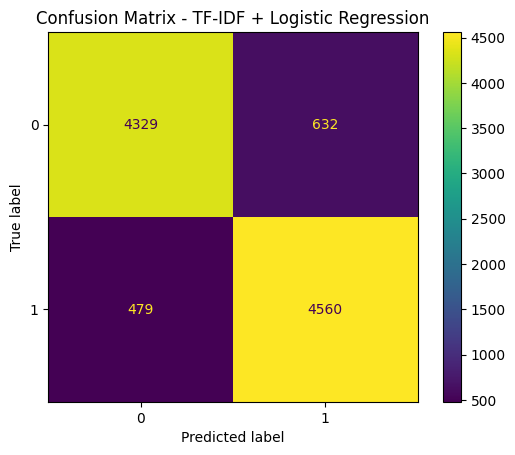


--- SAMPLE PREDICTIONS ---

Review: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev ...
Actual: 1 Predicted: 0

Review: Not many television shows appeal to quite as many different kinds of fans like Farscape does...I know youngsters and 30/40+ years old;fans both Male and Female in as many different countries as you ca ...
Actual: 1 Predicted: 1

Review: The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy hijacking Steven Seagal would have been beaten to pulp by Seagal's driving, but tha ...
Actual: 0 Predicted: 0


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# ── Load Dataset ──────────────────────────────────────────────────────────────
# On Kaggle use the path below. Locally, update the path to your CSV file.
df = pd.read_csv("/kaggle/working/IMDB Dataset.csv")
print("Dataset Loaded:", df.shape)
print(df.head())

# ── Encode Labels: positive=1, negative=0 ────────────────────────────────────
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# ── Train-Test Split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

# ── TF-IDF Vectorization ──────────────────────────────────────────────────────
# max_features=5000 means we only keep the 5000 most important words
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

# ── Train Logistic Regression ─────────────────────────────────────────────────
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# ── Evaluate ──────────────────────────────────────────────────────────────────
preds    = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, preds)
print("\nAccuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, preds))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
ConfusionMatrixDisplay.from_predictions(y_test, preds)
plt.title("Confusion Matrix - TF-IDF + Logistic Regression")
plt.show()

# ── Sample Predictions ────────────────────────────────────────────────────────
print("\n--- SAMPLE PREDICTIONS ---")
for i in range(3):
    print("\nReview:", X_test.iloc[i][:200], "...")
    print("Actual:", y_test.iloc[i], "Predicted:", preds[i])

### Part B — Word Embeddings: Word2Vec vs FastText vs GloVe

Instead of just counting words (TF-IDF), word embeddings represent each word as a **dense vector** that captures its *meaning*. Words with similar meanings end up close together in vector space.

- **Word2Vec** — Learns word vectors by predicting surrounding words
- **FastText** — Extension of Word2Vec; also considers sub-word (character-level) information
- **GloVe** — Pre-trained vectors trained on massive text corpora (Wikipedia + news)

In [12]:
#import urllib.request
#import zipfile
#import os

# Download Glove from Stanford (official source)
#print("Downloading Glove...")
#urllib.request.urlretrieve(
   # "https://nlp.stanford.edu/data/glove.6B.zip",
   # "glove.6B.zip"
#)

# Unzipping it 
#with zipfile.ZipFile("glove.6B.zip","r") as zip_ref:
    #zip_ref.extractall("glove")

#print("Done ! File extracted to /glove/")

In [13]:
import re
import numpy as np
from gensim.models import Word2Vec, FastText
from tqdm import tqdm

# ── Preprocess: Tokenize reviews into word lists ──────────────────────────────
def preprocess(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)      # remove HTML tags like <br />
    text = re.sub(r'[^a-z\s]', '', text)   # keep only letters
    return text.split()

df['tokens'] = df['review'].apply(preprocess)

# ── Train-Test Split on tokens ───────────────────────────────────────────────
train_tokens, test_tokens, y_train, y_test = train_test_split(
    df['tokens'], df['sentiment'], test_size=0.2, random_state=42
)

In [14]:
# ── Train Word2Vec Model ──────────────────────────────────────────────────────
# vector_size=100: each word is represented as a 100-dimensional vector
# window=5: look at 5 words around each target word for context
# min_count=2: ignore words that appear less than 2 times
w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

# ── Train FastText Model ──────────────────────────────────────────────────────
ft_model = FastText(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

# ── Load Pre-trained GloVe Vectors ────────────────────────────────────────────
# Add this dataset on Kaggle: search "GloVe 6B 100d" → danielwillgeorge
glove_path = "/kaggle/working/glove/glove.6B.100d.txt"
glove_dict = {}
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word   = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_dict[word] = vector
print(f"GloVe loaded: {len(glove_dict)} words")

GloVe loaded: 400000 words


In [15]:
# ── Convert each review to a single vector (average of all word vectors) ──────
def sentence_vector(tokens, model, emb_type="w2v"):
    """Average all word vectors in a review to get one review vector."""
    vectors = []
    for word in tokens:
        if emb_type == "glove":
            if word in model:
                vectors.append(model[word])
        else:
            if word in model.wv:
                vectors.append(model.wv[word])
    if len(vectors) == 0:
        return np.zeros(100)    # if no known words, return zero vector
    return np.mean(vectors, axis=0)

def create_features(token_series, model, emb_type):
    return np.array([
        sentence_vector(tokens, model, emb_type)
        for tokens in tqdm(token_series)
    ])

# ── Create feature matrices for all 3 embedding types ────────────────────────
X_train_w2v   = create_features(train_tokens, w2v_model, "w2v")
X_test_w2v    = create_features(test_tokens,  w2v_model, "w2v")

X_train_ft    = create_features(train_tokens, ft_model, "fasttext")
X_test_ft     = create_features(test_tokens,  ft_model, "fasttext")

X_train_glove = create_features(train_tokens, glove_dict, "glove")
X_test_glove  = create_features(test_tokens,  glove_dict, "glove")

100%|██████████| 10000/10000 [00:01<00:00, 6164.71it/s]



Word2Vec Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      4961
           1       0.83      0.85      0.84      5039

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



<Figure size 1000x500 with 0 Axes>

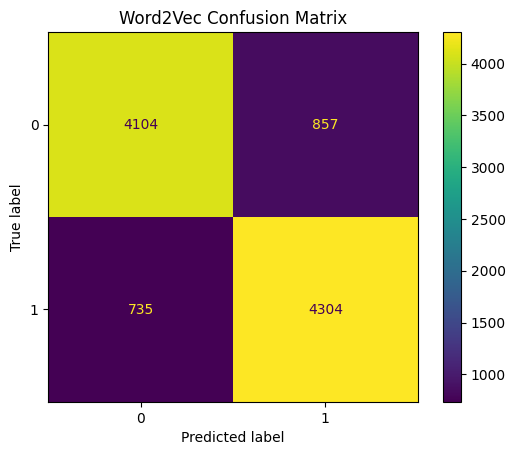


FastText Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.83      4961
           1       0.83      0.84      0.83      5039

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



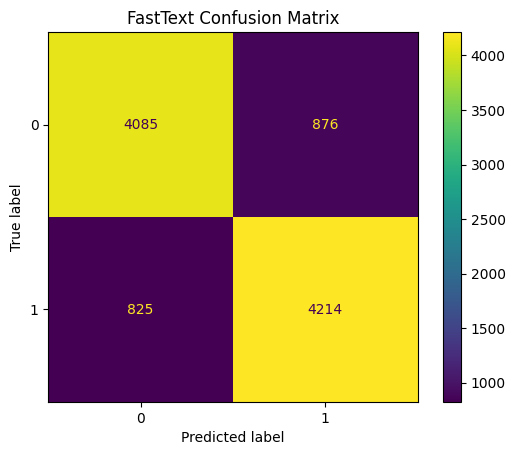


GloVe Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      4961
           1       0.81      0.79      0.80      5039

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



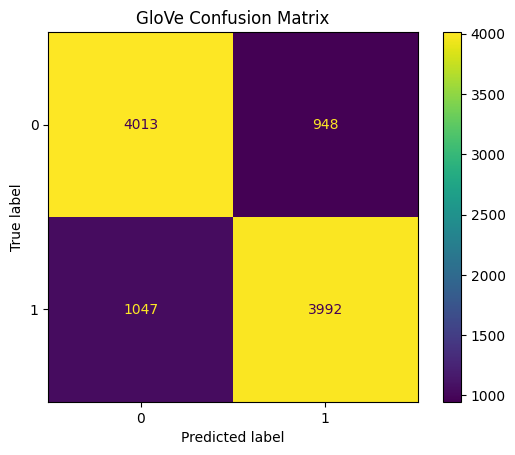


Model Comparison Table:
  Embedding  Accuracy
0  Word2Vec    0.8408
1  FastText    0.8299
2     GloVe    0.8005


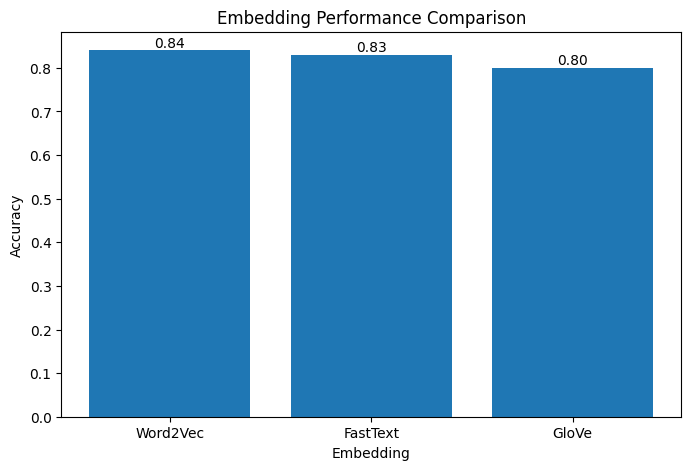


Best Model: Word2Vec


In [16]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── Train and evaluate each embedding ────────────────────────────────────────
models_emb = {
    "Word2Vec": (X_train_w2v,   X_test_w2v),
    "FastText": (X_train_ft,    X_test_ft),
    "GloVe"   : (X_train_glove, X_test_glove)
}

results = []

plt.figure(figsize=(10, 5))
for name, (X_tr, X_te) in models_emb.items():
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_tr, y_train)
    preds = clf.predict(X_te)
    acc   = accuracy_score(y_test, preds)
    results.append((name, acc))

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, preds))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()

# ── Model Comparison Table ────────────────────────────────────────────────────
df_results = pd.DataFrame(results, columns=["Embedding", "Accuracy"])
df_results = df_results.sort_values(by="Accuracy", ascending=False)
print("\nModel Comparison Table:")
print(df_results)

# ── Bar Chart ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
bars = plt.bar(df_results["Embedding"], df_results["Accuracy"])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.2f}", ha='center', va='bottom')
plt.xlabel("Embedding")
plt.ylabel("Accuracy")
plt.title("Embedding Performance Comparison")
plt.show()

print("\nBest Model:", df_results.iloc[0]["Embedding"])

---
## Practical 9 — Text Classifier Using Keras (Bidirectional LSTM)

**Aim:** Build and train a deep learning text classifier using Keras on the IMDB dataset.

**Model Architecture:**
- **Embedding Layer** — Converts word indices into dense vectors
- **Bidirectional LSTM** — Reads the sequence both forward AND backward, capturing more context
- **Dropout** — Randomly turns off neurons during training to prevent overfitting
- **Dense Layer** — Final layer with sigmoid activation for binary classification (positive/negative)
- **EarlyStopping** — Automatically stops training when the model stops improving

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# ── Load Dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv("/kaggle/working/IMDB Dataset.csv")

# ── Encode Labels ─────────────────────────────────────────────────────────────
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# ── Train-Test Split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

# ── Tokenization ─────────────────────────────────────────────────────────────
# vocab_size=10000 means we keep only the 10,000 most common words
vocab_size = 10000
tokenizer  = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# ── Padding ───────────────────────────────────────────────────────────────────
# All reviews are made the same length (300 words) by padding with zeros
max_len     = 300
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post')

print(f"Training samples: {X_train_pad.shape}")
print(f"Testing  samples: {X_test_pad.shape}")

2026-04-25 22:00:55.857783: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777154456.103979    1094 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777154456.165110    1094 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777154456.701589    1094 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777154456.701623    1094 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777154456.701626    1094 computation_placer.cc:177] computation placer alr

Training samples: (40000, 300)
Testing  samples: (10000, 300)


In [18]:
# ── Build Optimized Bidirectional LSTM Model ───────────────────────────────────
model = Sequential([
    Embedding(vocab_size, 128),                         # word → 128-dim vector
    Bidirectional(LSTM(64, return_sequences=True)),      # reads forward + backward
    Dropout(0.3),
    Bidirectional(LSTM(32)),                            # second LSTM layer
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')                     # output: 0 or 1
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.build(input_shape=(None, max_len))
model.summary()

2026-04-25 22:01:25.847006: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 300, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 300, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,424,257 (5.43 MB)

 Trainable params: 1,424,257 (5.43 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ── Train Model ───────────────────────────────────────────────────────────────
# EarlyStopping stops training if validation loss doesn't improve for 2 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 227s 886ms/step - accuracy: 0.6477 - loss: 0.6063 - val_accuracy: 0.8555 - val_loss: 0.3681
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 219s 874ms/step - accuracy: 0.8815 - loss: 0.3147 - val_accuracy: 0.8779 - val_loss: 0.3061
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 218s 873ms/step - accuracy: 0.9179 - loss: 0.2316 - val_accuracy: 0.8832 - val_loss: 0.3339
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 218s 871ms/step - accuracy: 0.9360 - loss: 0.1817 - val_accuracy: 0.8751 - val_loss: 0.3365


313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step

Accuracy: 0.8816

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88      4961
           1       0.89      0.87      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



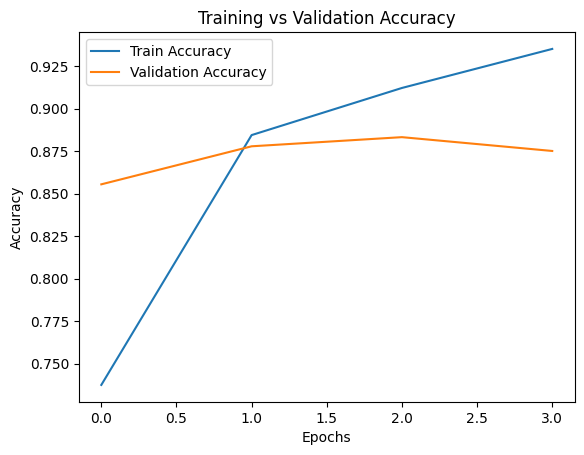

In [20]:
# ── Evaluate ──────────────────────────────────────────────────────────────────
preds = model.predict(X_test_pad)
preds = (preds > 0.5).astype(int).flatten()

print("\nAccuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds))

# ── Plot Training vs Validation Accuracy ─────────────────────────────────────
plt.figure()
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

---
## Practical 10 — Character-Level Text Generation Using LSTM

**Aim:** Train an LSTM model to predict the *next character* given a sequence of characters, then generate new text.

**How it works:**
1. Load a text dataset (Shakespeare's writings)
2. Create training pairs: input = 40 characters → output = the next 1 character
3. Train LSTM to learn these character-level patterns
4. At generation time, give the model a *seed* string and let it generate text character by character

**Temperature:**
- **Low (0.2–0.5)** → Safe, repetitive, predictable output
- **High (0.8–1.2)** → Creative, diverse, sometimes random output

> **Dataset path on Kaggle** (add dataset: *shakespeare-txt* → mohammedmohsen0404):  
> `/kaggle/input/shakespeare-txt/shakespeare.txt`

In [21]:
import numpy as np
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical

# ── Load Shakespeare dataset ──────────────────────────────────────────────────
with open("/kaggle/working/shakespeare.txt", "r") as f:
    text = f.read().lower()

# Skip the header/intro (first 1000 chars) for better training quality
text = text[1000:50000]
print(f"Text length: {len(text)} characters")
print(f"Sample: {text[:100]}")

Text length: 49000 characters
Sample: w;
    but i must attend his majesty's command, to whom i am now in
    ward, evermore in subjection


In [22]:
# ── Character-level Encoding ──────────────────────────────────────────────────
chars      = sorted(list(set(text)))
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}
vocab_size = len(chars)

print(f"Unique characters: {vocab_size}")
print(f"Characters: {chars}")

Unique characters: 42
Characters: ['\n', ' ', '!', '"', "'", ',', '-', '.', '1', '2', '3', ':', ';', '?', '[', ']', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [23]:
# ── Prepare Training Sequences ────────────────────────────────────────────────
# For every 40 characters in the text → predict the 41st character
seq_length = 40
X_list, y_list = [], []

for i in range(len(text) - seq_length):
    seq    = text[i : i + seq_length]
    target = text[i + seq_length]
    X_list.append([char_to_idx[c] for c in seq])
    y_list.append(char_to_idx[target])

X = np.array(X_list)
y = to_categorical(y_list, num_classes=vocab_size)

# Normalize input to range [0, 1]
X = X / float(vocab_size)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))  # shape: (samples, 40, 1)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (48960, 40, 1)
y shape: (48960, 42)


In [24]:
# ── Build the Character-Level LSTM Model ──────────────────────────────────────
model = Sequential([
    LSTM(128, input_shape=(seq_length, 1)),   # reads the 40-char input sequence
    Dense(vocab_size, activation='softmax')   # outputs probabilities for each character
])

model.compile(loss='categorical_crossentropy', optimizer='adam')
model.build(input_shape=(None, seq_length, 1))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 42)             │         5,418 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,978 (281.16 KB)

 Trainable params: 71,978 (281.16 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# ── Train Model ───────────────────────────────────────────────────────────────
# More epochs = better quality text generation
# 10 epochs is enough to demonstrate the workflow on Kaggle with GPU
model.fit(X, y, epochs=40, batch_size=64)

Epoch 1/40
765/765 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - loss: 2.4277
Epoch 2/40
765/765 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - loss: 2.4201
Epoch 3/40
765/765 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - loss: 2.4057
Epoch 4/40
765/765 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - loss: 2.3987
Epoch 5/40
765/765 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - loss: 2.3718
Epoch 6/40
765/765 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - loss: 2.3501
Epoch 7/40
765/765 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - loss: 2.3451
Epoch 8/40
765/765 ━━━━━━━━━━━━━━━━━━━━ 35s 46ms/step - loss: 2.3381
Epoch 9/40
765/765 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - loss: 2.3400
Epoch 10/40
765/765 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - loss: 2.3216
Epoch 11/40
765/765 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - loss: 2.3117
Epoch 12/40
765/765 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - loss: 2.2929
Epoch 13/40
765/765 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - loss: 2.2861
Epoch 14/40
765/765 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - loss: 2.2555
Epoch 15/40
765/765 ━━━━━━━━━

In [34]:
# ── Predict Next Character ────────────────────────────────────────────────────
def predict_next_char(incomplete_word):
    """
    Give it any sequence/word with one letter missing,
    and it predicts the very next character.
    Example: "shakespear" → predicts "e" → "shakespeare"
    """
    # Take last 40 characters, pad with spaces if shorter
    sequence = incomplete_word[-seq_length:].ljust(seq_length)

    # Convert each character to its index number
    x_input = np.array([char_to_idx.get(c, 0) for c in sequence])

    # Normalize and reshape for model input
    x_input = x_input / float(vocab_size)
    x_input = np.reshape(x_input, (1, seq_length, 1))

    # Get predictions (probability for each character)
    pred = model.predict(x_input, verbose=0)[0]

    # Remove space from predictions by setting its probability to 0
    space_idx = char_to_idx.get(' ', -1)
    if space_idx >= 0:
        pred[space_idx] = 0.0

    # Renormalize so probabilities add up to 1 again
    pred = pred / np.sum(pred)

    # Now pick the most likely non-space character
    next_char = idx_to_char[np.argmax(pred)]

    print(f"Input     : '{incomplete_word}'")
    print(f"Next char : '{next_char}'")
    print(f"Completed : '{incomplete_word + next_char}'")
    print("-" * 40)

print("=" * 40)
print("NEXT CHARACTER PREDICTION")
print("=" * 40)
predict_next_char("shakespear")
predict_next_char("to be or not to b")
predict_next_char("fortune, she sai")
predict_next_char("the lady doth protes")
predict_next_char("all the worl")
predict_next_char("the lad")

NEXT CHARACTER PREDICTION
Input     : 'shakespear'
Next char : 'e'
Completed : 'shakespeare'
----------------------------------------
Input     : 'to be or not to b'
Next char : 'e'
Completed : 'to be or not to be'
----------------------------------------
Input     : 'fortune, she sai'
Next char : 'e'
Completed : 'fortune, she saie'
----------------------------------------
Input     : 'the lady doth protes'
Next char : 'e'
Completed : 'the lady doth protese'
----------------------------------------
Input     : 'all the worl'
Next char : 'e'
Completed : 'all the worle'
----------------------------------------
Input     : 'the lad'
Next char : 'e'
Completed : 'the lade'
----------------------------------------
